In [1]:
from varchar import *
import matplotlib.pyplot as plt
import numpy as np

In [2]:
embedder = StrEmbedder()
text = "Hello"

indices = embedder.encode_chars(text)
indices

tensor([68, 39, 46, 46, 49])

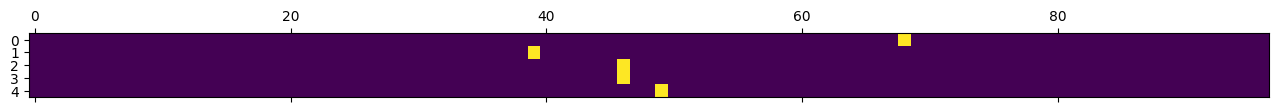

In [3]:
S = embedder.selection(indices)
plt.matshow(S)

In [4]:
result  = embedder.decode_selection(S)
result

tensor([[0., 0., 2., 0., 0., 0.],
        [0., 0., 0., 1., 0., 1.],
        [0., 0., 1., 1., 0., 0.],
        [0., 0., 1., 1., 0., 0.],
        [0., 0., 1., 1., 1., 1.]])

In [5]:
out_str = embedder.decode_str(result)
out_str

'Hello'

In [6]:
embeddings = embedder(indices)
embeddings

tensor([[0., 0., 2., 0., 0., 0.],
        [0., 0., 0., 1., 0., 1.],
        [0., 0., 1., 1., 0., 0.],
        [0., 0., 1., 1., 0., 0.],
        [0., 0., 1., 1., 1., 1.]])

In [7]:
collator = PaddedCollator(embedder, 'cpu')

dataset = ['Hi', 'Hello', 'World', 'Mars']

inputs, selections = collator(dataset)
inputs.shape, selections.shape

(torch.Size([4, 5, 6]), torch.Size([4, 5, 97]))

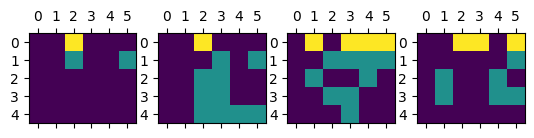

In [8]:
fig, axes = plt.subplots(1, len(inputs))  

for i, x in enumerate(inputs):
    axes[i].matshow(x) 

plt.show()

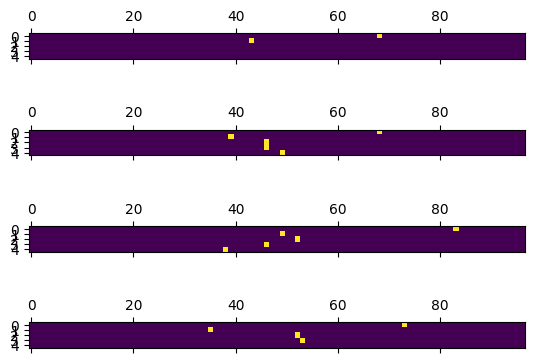

In [9]:
fig, axes = plt.subplots(len(selections), 1)  

for i, x in enumerate(selections):
    axes[i].matshow(x) 

plt.show()

In [10]:
selections[0]

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
  

In [11]:
selections[0,2,0] = 0
selections[0,3,0] = 0
selections[0]

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
  

In [12]:
embedder.decode_str(embedder.decode_selection(selections[0].float()))

'Hi'

In [13]:
x = [[1.0,2.0],
    [3.0,4.0]]
import torch.nn.functional as F
F.softmax(torch.tensor(x), dim=0)

tensor([[0.1192, 0.1192],
        [0.8808, 0.8808]])

In [14]:
inputs, selections = collator(["Hello Hi apple banana"])
inputs.shape

torch.Size([1, 21, 6])

In [15]:
inputs = inputs.squeeze(0)
inputs[0:4]

tensor([[0, 0, 2, 0, 0, 0],
        [0, 0, 0, 1, 0, 1],
        [0, 0, 1, 1, 0, 0],
        [0, 0, 1, 1, 0, 0]], dtype=torch.int32)

In [16]:
dataset = LinearStrDataset('Apache_2k.log')

In [17]:
d = dataset.processed

In [40]:
def padded_collator(batch):
    maxlen = max([b["input"].shape[0] for b in batch])
    padded_inputs     = torch.stack([F.pad(b["input"], (0, 0, 0, maxlen - b["input"].shape[0]), value=0) for b in batch])
    padded_selections = torch.stack([F.pad(b["selection"], (0, 0, 0, maxlen - b["selection"].shape[0]), value=0) for b in batch])
    padded_variations = torch.stack([F.pad(b["variation"], (0, 0, 0, maxlen - b["variation"].shape[0]), value=0) for b in batch])

    padded_batch = {
        "inputs": padded_inputs,
        "selections": padded_selections,
        "variations": padded_variations,
        "length": maxlen
    }

    return padded_batch

In [41]:
c = padded_collator(d[0:4])

In [43]:
c["variations"].shape

torch.Size([4, 91, 6])